# Quoter — Tests & Examples
Tests for the `Quoter` class: quoting logic, requote triggers, fill callbacks, and Quoter ↔ Order_book integration.


## 1. Imports

In [18]:
import importlib
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(r'../src/')

import utils.order_book.order_book_impl as book_utils
import utils.market_maker.quoter        as quoter_utils

from utils.order_book.order_book_impl import Order, Order_book
from utils.order_book.events          import FillEvent
from utils.market_maker.quoter        import Quoter, QuoterConfig, Quote


## 2. Lightweight Market stub
The `Quoter` only reads three arrays from a `Market`: `stock.vol`, `stock.time_step`, and
`noised_mid_price` / `bid_price` / `ask_price`.  
We build a minimal stub here so the notebook is self-contained — **no GBM simulation needed**.


In [19]:
from dataclasses import dataclass
import math

TRADING_SECONDS_PER_YEAR = 252 * 24 * 3600   # matches stock_simulation/config.py

@dataclass
class _Stock:
    vol:       float = 0.08
    time_step: float = 1.0          # 1 second per step

class FakeMarket:
    """Minimal Market stub: GBM-like prices, correct interface for Quoter."""
    def __init__(self, S0=1.0850, vol=0.08, half_spread_bps=2.0, n=30_000, seed=0):
        rng = np.random.default_rng(seed)
        dt  = 1.0 / TRADING_SECONDS_PER_YEAR
        lr  = (- 0.5*vol**2*dt + vol*math.sqrt(dt)*rng.standard_normal(n))
        mid = S0 * np.exp(np.cumsum(lr))
        h   = half_spread_bps / 10_000.0
        self.stock            = _Stock(vol=vol, time_step=1.0)
        self.noised_mid_price = mid
        self.bid_price        = mid * (1 - h)
        self.ask_price        = mid * (1 + h)

market_B = FakeMarket(S0=1.0850, vol=0.08,  half_spread_bps=1.8, n=30_000, seed=1)
market_C = FakeMarket(S0=1.0850, vol=0.085, half_spread_bps=2.2, n=30_000, seed=2)
print("Markets ready — mid0_B =", round(market_B.noised_mid_price[0], 5),
      "  mid0_C =", round(market_C.noised_mid_price[0], 5))


Markets ready — mid0_B = 1.08501   mid0_C = 1.085


## 3. Instantiate Quoter with default config

In [20]:
importlib.reload(quoter_utils)

cfg = QuoterConfig()   # all defaults — see quoter.py for parameter meaning
q   = Quoter(market_B, market_C, config=cfg, capital_K=1_000_000.0)

print("gamma              :", cfg.gamma)
print("k                  :", cfg.k)
print("T (session, hours) :", cfg.T / 3600)
print("n_levels           :", cfg.n_levels)
print("tick_size          :", cfg.tick_size)
print("delta_limit        :", cfg.delta_limit)
print("latency_B / C (ms) :", cfg.latency_B_s*1000, "/", cfg.latency_C_s*1000)
print("effective_gap (ms) :", round(q._effective_gap_s*1000, 1))


gamma              : 0.1
k                  : 1.5
T (session, hours) : 8.0
n_levels           : 10
tick_size          : 0.0001
delta_limit        : 0.9
latency_B / C (ms) : 200.0 / 170.0
effective_gap (ms) : 142.5


## 4. First `compute_quotes` call — cold start

No resting orders yet.  Expected: 20 quotes (10 bids + 10 asks), no cancels.


In [21]:
step, t = 500, 500.0
resting = {}   # empty — no MM orders in the book yet

quotes, cancel_ids = q.compute_quotes(step, t, resting)

bids = [x for x in quotes if x.direction == "buy"]
asks = [x for x in quotes if x.direction == "sell"]

print(f"Total quotes : {len(quotes)}  ({len(bids)} bids + {len(asks)} asks)")
print(f"Cancel IDs   : {cancel_ids}")
print()
print(f"{'Lvl':>3}  {'Bid size':>10}  {'Bid px':>8}  {'Ask px':>8}  {'Ask size':>10}")
print("-"*46)
for b, a in zip(bids, asks):
    print(f"{b.level:3d}  {b.size:10,.0f}  {b.price:8.4f}  {a.price:8.4f}  {a.size:10,.0f}")


Total quotes : 20  (10 bids + 10 asks)
Cancel IDs   : []

Lvl    Bid size    Bid px    Ask px    Ask size
----------------------------------------------
  1      74,082    1.0845    1.0847      74,082
  2      54,881    1.0844    1.0848      54,881
  3      40,657    1.0843    1.0849      40,657
  4      30,119    1.0842    1.0850      30,119
  5      22,313    1.0841    1.0851      22,313
  6      16,530    1.0840    1.0852      16,530
  7      12,246    1.0839    1.0853      12,246
  8       9,072    1.0838    1.0854       9,072
  9       6,721    1.0837    1.0855       6,721
 10       4,979    1.0836    1.0856       4,979


## 5. `snapshot` — inspect all spread components at a given step

In [22]:
snap = q.snapshot(step, t)

print(f"Fair mid           : {snap['fair_mid']:.5f}")
print(f"Reservation price  : {snap['reservation_price']:.5f}")
print(f"Best bid / ask     : {snap['best_bid']:.4f}  /  {snap['best_ask']:.4f}")
print(f"Spread (bps)       : {snap['spread_bps']:.2f}")
print()
print("── Spread decomposition ───────────────────────────")
mid = snap['fair_mid']
print(f"  A-S core     : {snap['spread_AS']       / mid * 10_000:.3f} bps")
print(f"  Latency      : {snap['spread_latency']  / mid * 10_000:.3f} bps")
print(f"  Inventory    : {snap['spread_inventory']/ mid * 10_000:.3f} bps")
print(f"  Total spread : {snap['total_spread']    / mid * 10_000:.3f} bps")
print()
print(f"Skew delta         : {snap['skew_delta']*10_000:.3f} bps")
print(f"Penalty factor     : {snap['penalty_factor']:.4f}")
print(f"Inventory          : {snap['inventory_EUR']:,.0f} EUR  ({snap['inventory_ratio']:.1%})")
print(f"Needs hedge        : {snap['needs_hedge']}")


Fair mid           : 1.08459
Reservation price  : 1.08459
Best bid / ask     : 1.0845  /  1.0847
Spread (bps)       : 1.84

── Spread decomposition ───────────────────────────
  A-S core     : 1.299 bps
  Latency      : 0.119 bps
  Inventory    : 0.000 bps
  Total spread : 1.418 bps

Skew delta         : 0.000 bps
Penalty factor     : 1.0000
Inventory          : 0 EUR  (0.0%)
Needs hedge        : False


## 6. Requote suppression — identical call returns empty lists

When market hasn't moved enough, `compute_quotes` returns `([], [])` to avoid unnecessary churn.


In [23]:
q2 = Quoter(market_B, market_C)
q2.compute_quotes(500, 500.0, {})   # prime _prev_best_bid/ask

quotes2, cancels2 = q2.compute_quotes(500, 500.0, {})   # same step — no change
print(f"Second call → {len(quotes2)} quotes, {len(cancels2)} cancels  (expected 0 / 0)")
assert len(quotes2) == 0, "should suppress requote on stable price"
print("Suppression: OK ✓")


Second call → 0 quotes, 0 cancels  (expected 0 / 0)
Suppression: OK ✓


## 7. `on_fill` callback — inventory update & pending fill queue

`on_fill` is called by the `Order_book` via the registered callback.  
Full fills queue a forced requote; partial fills only update inventory.


In [24]:
q3 = Quoter(market_B, market_C)

# Simulate a full fill on a sell (our ask got hit — client bought)
e1 = FillEvent(order_id="O1", direction="sell", price=1.0852,
               size=50_000.0, step=100, is_full_fill=True)
q3.on_fill(e1)
print(f"After full fill  → inventory: {q3.inventory:,.0f} EUR  pending: {len(q3._pending_fills)}")

# Partial fill on a buy (our bid got partially hit)
e2 = FillEvent(order_id="O2", direction="buy", price=1.0848,
               size=20_000.0, step=101, is_full_fill=False)
q3.on_fill(e2)
print(f"After partial fill → inventory: {q3.inventory:,.0f} EUR  pending: {len(q3._pending_fills)}")

# The full fill should force a requote even if price didn't move
quotes3, cancels3 = q3.compute_quotes(500, 500.0, {})
print(f"compute_quotes after full fill → {len(quotes3)} quotes  (expected 20)")


After full fill  → inventory: -50,000 EUR  pending: 1
After partial fill → inventory: -30,000 EUR  pending: 1
compute_quotes after full fill → 20 quotes  (expected 20)


## 8. Cancel logic — drift, stale orders, filled orders

`compute_quotes` selectively cancels resting orders based on three rules:
- **Rule 1**: order was fully filled (ID appears in pending fills)
- **Rule 2**: resting price has drifted beyond the threshold fraction of spread
- **Rule 3**: order is stale AND inventory is stressed


In [25]:
q4 = Quoter(market_B, market_C)
# Prime _prev_best_bid/ask
quotes_init, _ = q4.compute_quotes(1000, 1000.0, {})
best_bid = q4._prev_best_bid
best_ask = q4._prev_best_ask

# Fabricate three resting orders
resting = {
    "O_ok":    {"direction": "buy",  "price": best_bid,          "age": 10},    # fine
    "O_drift": {"direction": "buy",  "price": best_bid - 0.02,   "age": 10},    # 200 pip drift → Rule 2
    "O_stale": {"direction": "sell", "price": best_ask,           "age": 9999},  # stale → Rule 3 if stressed
}

# Stress inventory to trigger Rule 3
q4.inventory = q4.capital_K * (q4.cfg.stale_inventory_fraction + 0.05)

# Force a requote by injecting a full fill
q4._pending_fills.append(FillEvent("O_filled", "buy", best_bid, 1000.0, 1000, True))

quotes4, cancels4 = q4.compute_quotes(1000, 1000.0, resting)

print("Cancelled:", cancels4)
print("O_drift cancelled :", "O_drift"  in cancels4)
print("O_stale cancelled :", "O_stale"  in cancels4)
print("O_ok    cancelled :", "O_ok"     in cancels4)


Cancelled: ['O_ok', 'O_drift', 'O_stale']
O_drift cancelled : True
O_stale cancelled : True
O_ok    cancelled : True


## 9. Session reset — FX boundary (Tokyo → London → NY)

At each FX session boundary (00:00, 08:00, 16:00 UTC) the Quoter cancels **all** resting orders and requotes fresh.


In [26]:
q5 = Quoter(market_B, market_C)
q5._last_session_reset_t = 8*3600 - 2.0   # just before London open

resting5 = {
    "OA": {"direction": "buy",  "price": 1.0848, "age": 500},
    "OB": {"direction": "sell", "price": 1.0852, "age": 500},
    "OC": {"direction": "buy",  "price": 1.0847, "age": 1000},
}

t_london = 8*3600 + 0.5   # just past the boundary
quotes5, cancels5 = q5.compute_quotes(step=28_802, t=t_london, resting_orders=resting5)

print(f"Session reset at t={t_london}s (London open)")
print(f"  Quotes   : {len(quotes5)}  (expected 20)")
print(f"  Cancels  : {cancels5}  (expected all 3)")
assert set(cancels5) == set(resting5.keys())
print("Session reset: OK ✓")


Session reset at t=28800.5s (London open)
  Quotes   : 20  (expected 20)
  Cancels  : ['OA', 'OB', 'OC']  (expected all 3)
Session reset: OK ✓


## 10. Inventory skew — how the ladder tilts with long/short position

When long EUR, the Quoter widens the bid half-spread and narrows the ask to incentivise clients to buy from us.


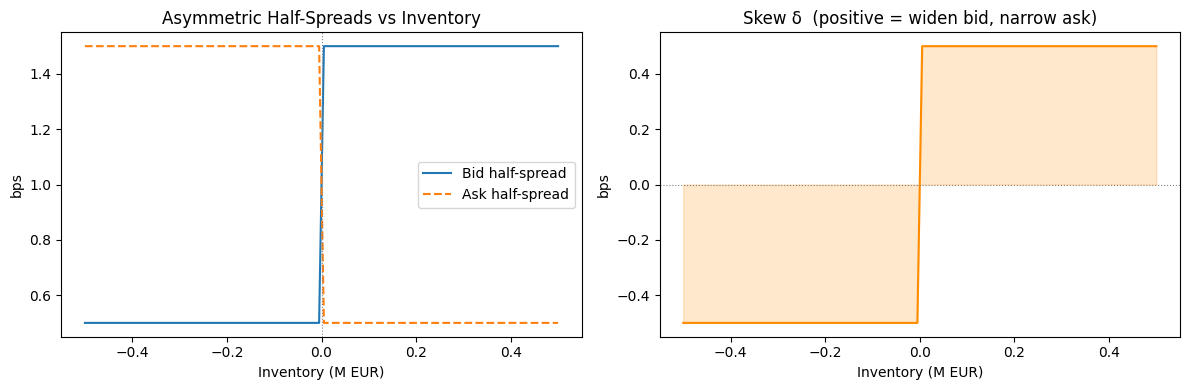

In [27]:
inventories = np.linspace(-500_000, 500_000, 100)
rows = []
for inv in inventories:
    q_tmp = Quoter(market_B, market_C)
    q_tmp.inventory = inv
    s = q_tmp.snapshot(1000, 1000.0)
    rows.append({"inv": inv, "bid_half": s["bid_half"], "ask_half": s["ask_half"],
                 "skew_delta": s["skew_delta"], "spread_bps": s["spread_bps"]})

df = pd.DataFrame(rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(df.inv/1e6, df.bid_half*10_000, label="Bid half-spread")
ax1.plot(df.inv/1e6, df.ask_half*10_000, label="Ask half-spread", ls="--")
ax1.axvline(0, color="grey", lw=0.8, ls=":")
ax1.set_xlabel("Inventory (M EUR)"); ax1.set_ylabel("bps")
ax1.set_title("Asymmetric Half-Spreads vs Inventory"); ax1.legend()

ax2.plot(df.inv/1e6, df.skew_delta*10_000, color="darkorange")
ax2.axhline(0, color="grey", lw=0.8, ls=":")
ax2.fill_between(df.inv/1e6, df.skew_delta*10_000, alpha=0.2, color="darkorange")
ax2.set_xlabel("Inventory (M EUR)"); ax2.set_ylabel("bps")
ax2.set_title("Skew δ  (positive = widen bid, narrow ask)")

plt.tight_layout(); plt.show()


## 11. Spread decomposition over a full 8-hour session

<>:20: SyntaxWarning: invalid escape sequence '\k'
<>:20: SyntaxWarning: invalid escape sequence '\k'
/var/folders/4s/vm5vvky129dc6qm4gb3wvqzm0000gn/T/ipykernel_28335/561008836.py:20: SyntaxWarning: invalid escape sequence '\k'
  ax.set_title("Terminal Penalty  $1 + \kappa (t/T)^3$")


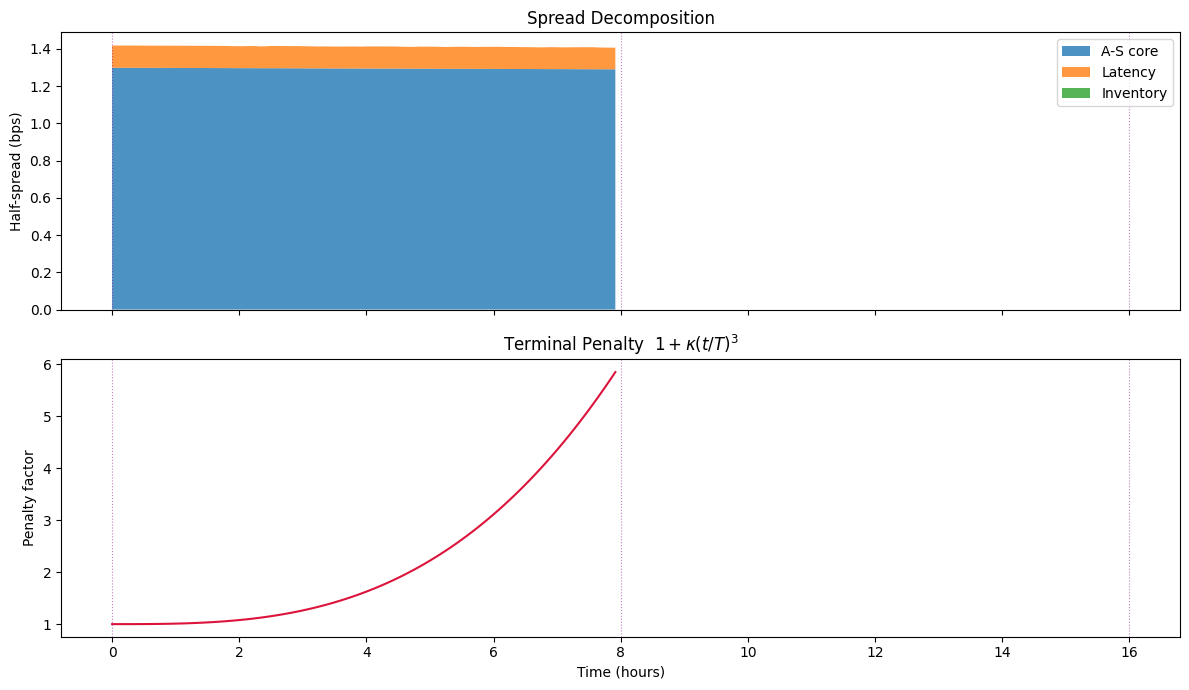

In [28]:
q6   = Quoter(market_B, market_C)
T_s  = int(q6.cfg.T)
snaps = [q6.snapshot(s, float(s)) for s in range(0, T_s, 300)]
df6   = pd.DataFrame(snaps)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
bps = 10_000.0 / df6.fair_mid

ax = axes[0]
ax.stackplot(df6.t_seconds/3600,
             df6.spread_AS        * bps,
             df6.spread_latency   * bps,
             df6.spread_inventory * bps,
             labels=["A-S core", "Latency", "Inventory"], alpha=0.8)
ax.set_ylabel("Half-spread (bps)"); ax.set_title("Spread Decomposition"); ax.legend()

ax = axes[1]
ax.plot(df6.t_seconds/3600, df6.penalty_factor, color="crimson")
ax.set_xlabel("Time (hours)"); ax.set_ylabel("Penalty factor")
ax.set_title("Terminal Penalty  $1 + \kappa (t/T)^3$")

for bdry in [0, 8, 16]:
    for a in axes: a.axvline(bdry, color="purple", lw=0.8, ls=":", alpha=0.5)

plt.tight_layout(); plt.show()


## 12. Quoter ↔ Order_book integration

This mirrors the order_book notebook pattern:
1. Seed the book with MM quotes from the Quoter
2. Register the Quoter fill callback on the book
3. Submit client orders → matching fires FillEvents → inventory updates automatically
4. Inspect matches and observe the Quoter's response


In [29]:
importlib.reload(book_utils)
importlib.reload(quoter_utils)

# ── Fresh Quoter + fresh Order_book ────────────────────────────────────────
q_int = Quoter(market_B, market_C)
ob    = Order_book()

# Register the Quoter as a fill listener on the book
ob.register_quoter_listener(q_int.on_fill)

# ── Step 1: get Quoter's initial ladder ────────────────────────────────────
step, t = 500, 500.0
quotes_int, _ = q_int.compute_quotes(step, t, {})

# Submit MM quotes to the book
for qt in quotes_int:
    ob.add_order(Order(
        id        = f"MM_{qt.direction}_{qt.level}",
        direction = qt.direction,
        price     = qt.price,
        size      = qt.size,
        type      = "limit_order",
        origin    = "market_maker",
    ))

print(f"MM book seeded: {len(ob._df_order_book)} orders")
print(f"  Best bid : {ob._df_bid_book['Price'].max():.4f}")
print(f"  Best ask : {ob._df_ask_book['Price'].min():.4f}")
print(f"  Resting registry: {len(ob.mm_resting_orders)} MM orders tracked")


MM book seeded: 20 orders
  Best bid : 1.0845
  Best ask : 1.0847
  Resting registry: 20 MM orders tracked


In [30]:
# ── Step 2: submit aggressive client orders that will cross the spread ─────
best_bid = ob._df_bid_book['Price'].max()
best_ask = ob._df_ask_book['Price'].min()

client_orders = [
    # Client buys at best ask (hits MM ask)
    Order("C_buy_1",  "buy",  best_ask + 0.0002, 80_000, "limit_order", "client"),
    Order("C_buy_2",  "buy",  best_ask + 0.0001, 60_000, "limit_order", "client"),
    # Client sells at best bid (hits MM bid)
    Order("C_sell_1", "sell", best_bid - 0.0002, 50_000, "limit_order", "client"),
]

ob.add_orders_batch(client_orders)

print(f"Matches: {len(ob._df_matches)}")
print(ob._df_matches[["Direction", "Price", "MatchedSize", "ClientOrderId", "MmOrderId"]])
print(f"\nQuoter inventory after fills: {q_int.inventory:,.0f} EUR")
print(f"Pending fills queued        : {len(q_int._pending_fills)}")
print(f"Fill history entries        : {len(q_int._fill_history)}")


Adding orders: 100%|██████████| 3/3 [00:00<00:00, 126.60it/s]

Matches: 4
  Direction   Price  MatchedSize ClientOrderId  MmOrderId
0       buy  1.0847     74081.82       C_buy_1  MM_sell_1
1       buy  1.0848      5918.18       C_buy_1  MM_sell_2
2       buy  1.0848     48962.98       C_buy_2  MM_sell_2
3      sell  1.0845     50000.00      C_sell_1   MM_buy_1

Quoter inventory after fills: -123,045 EUR
Pending fills queued        : 2
Fill history entries        : 2


In [31]:
# ── Step 3: tick the book (age orders) then ask Quoter for updated quotes ──
ob.tick(step + 1)

resting_now = ob.mm_resting_orders
quotes_new, cancel_ids = q_int.compute_quotes(step + 1, t + 1.0, resting_now)

print(f"Orders to cancel : {len(cancel_ids)}  (filled or drifted)")
print(f"New quotes       : {len(quotes_new)}")
print(f"Inventory ratio  : {q_int.inventory / q_int.capital_K:.2%}")

# Apply cancels + new quotes to the book
ob.cancel_orders(cancel_ids)
for qt in quotes_new:
    ob.add_order(Order(
        id        = f"MM2_{qt.direction}_{qt.level}",
        direction = qt.direction,
        price     = qt.price,
        size      = qt.size,
        type      = "limit_order",
        origin    = "market_maker",
    ))

print(f"\nOrder book after requote: {len(ob._df_order_book)} orders")
print(f"  MM orders  : {(ob._df_order_book['Origin']=='market_maker').sum()}")
print(f"  Client left: {(ob._df_order_book['Origin']=='client').sum()}")


Orders to cancel : 18  (filled or drifted)
New quotes       : 20
Inventory ratio  : -12.30%

Order book after requote: 21 orders
  MM orders  : 20
  Client left: 1


## 13. Hedge trigger — `needs_hedge` and `hedge_order`

In [32]:
q7 = Quoter(market_B, market_C, capital_K=1_000_000.0)

print(f"delta_limit = {q7.cfg.delta_limit:.0%}")
print()

for inv in [0, 500_000, 850_000, 950_000]:
    q7.inventory = inv
    snap = q7.snapshot(500, 500.0)
    flag = q7.needs_hedge()
    print(f"  inventory={inv:>10,.0f}  ratio={snap['inventory_ratio']:>6.1%}  needs_hedge={flag}")

print()
q7.inventory = 950_000.0
size_B, size_C, fee = q7.hedge_order(
    market_B_depth=500_000.0,
    market_C_depth=300_000.0,
    fair_mid=snap['fair_mid'],
)
print(f"Hedge: send {size_B:,.0f} EUR to B  +  {size_C:,.0f} EUR to C")
print(f"       total = {size_B+size_C:,.0f}  (target = {-q7.inventory:,.0f})")
print(f"       fee cost = {fee:.4f} EUR")


delta_limit = 90%

  inventory=         0  ratio=  0.0%  needs_hedge=False
  inventory=   500,000  ratio= 50.0%  needs_hedge=False
  inventory=   850,000  ratio= 85.0%  needs_hedge=False
  inventory=   950,000  ratio= 95.0%  needs_hedge=True

Hedge: send -570,000 EUR to B  +  -380,000 EUR to C
       total = -950,000  (target = -950,000)
       fee cost = 247.2869 EUR
